# ENEM 2018–2022 × Desigualdade socioeconômica


## Como usar em outra máquina
Todos os caminhos e a leitura dos dados estão na célula **0. Configuração e carregamento**. Ajuste `BASE`

## Medidas
- **Renda (Q006):** 17 faixas A–Q → rank ordinal 1–17.
- **Rede:** `TP_DEPENDENCIA_ADM_ESC` — Pública = {Federal, Estadual, Municipal}, Privada = {Privada}.
- **Desempenho:** `MEDIA` = média das 5 notas (4 objetivas + redação), só para quem fez as 5 provas.


## 0. Configuração e carregamento



In [21]:

import pandas as pd, numpy as np, math
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# BASE = Path(r'C:/Users/Berna/Downloads/Coleta de Dados')
BASE = Path.cwd()
YEARS = [2018, 2019, 2020, 2021, 2022]

ENEM_FILES = {y: BASE / f'microdados_enem_{y}' / 'DADOS' / f'MICRODADOS_ENEM_{y}.csv' for y in YEARS}
IVS_FILE  = BASE / 'IVS - Copy.xls'
IDHM_FILE = BASE / 'IDHM - Copy.xls'

REG = {'AC':'Norte','AP':'Norte','AM':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
       'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste','PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
       'DF':'Centro-Oeste','GO':'Centro-Oeste','MT':'Centro-Oeste','MS':'Centro-Oeste',
       'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
       'PR':'Sul','RS':'Sul','SC':'Sul'}
NOTAS = ['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
PRES  = ['TP_PRESENCA_CN','TP_PRESENCA_CH','TP_PRESENCA_LC','TP_PRESENCA_MT']
INC = {c:i+1 for i,c in enumerate('ABCDEFGHIJKLMNOPQ')}
regs = ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']
CHUNK = 700_000

_NORM = {'centro-oeste':'Centro-Oeste','norte':'Norte','nordeste':'Nordeste','sul':'Sul','sudeste':'Sudeste'}
def ler_indicador(path):
    df = pd.read_excel(path, sheet_name='Séries')
    df = df.rename(columns={'Região':'Regiao'})
    df['Regiao'] = (df['Regiao'].astype(str).str.replace('Região','',regex=False)
                    .str.strip().str.lower().map(_NORM))
    anos = [c for c in df.columns if str(c).split('.')[0].isdigit() and int(str(c).split('.')[0]) in YEARS]
    out = df.dropna(subset=['Regiao']).set_index('Regiao')[anos]
    out.columns = [int(str(c).split('.')[0]) for c in anos]
    return out.reindex(regs)

idhm_df = ler_indicador(IDHM_FILE)
ivs_df  = ler_indicador(IVS_FILE)
IDHM = {rg: idhm_df.loc[rg].tolist() for rg in regs}
IVS  = {rg: ivs_df.loc[rg].tolist()  for rg in regs}

faltando = [str(p) for p in list(ENEM_FILES.values())+[IVS_FILE, IDHM_FILE] if not p.exists()]
print('Tudo encontrado!' if not faltando else 'FALTAM:\n- ' + '\n- '.join(faltando))
display(idhm_df.round(3)); display(ivs_df.round(3))

Tudo encontrado!


,2018,2019,2020,2021,2022
Regiao,,,,,
Norte,0.732,0.732,0.730,0.705,0.747
Nordeste,0.723,0.729,0.728,0.713,0.740
Centro-Oeste,0.790,0.797,0.787,0.767,0.808
Sudeste,0.806,0.813,0.803,0.783,0.813
Sul,0.795,0.799,0.794,0.774,0.802


,2018,2019,2020,2021,2022
Regiao,,,,,
Norte,0.285,0.286,0.276,0.297,0.260
Nordeste,0.297,0.300,0.303,0.319,0.270
Centro-Oeste,0.231,0.234,0.240,0.240,0.213
Sudeste,0.230,0.224,0.234,0.241,0.204
Sul,0.184,0.177,0.186,0.180,0.165


## 1. Processamento dos microdados por ano


In [22]:
def corr_from_sums(s):
    n, sx, sy, sxx, syy, sxy = s
    den = math.sqrt(max(n*sxx - sx*sx, 0) * max(n*syy - sy*sy, 0))
    return (n*sxy - sx*sy)/den if den > 0 else np.nan

def process_year(y):
    usecols = ['TP_DEPENDENCIA_ADM_ESC','TP_LOCALIZACAO_ESC','SG_UF_PROVA','Q006'] + NOTAS + PRES
    inc_reg = defaultdict(lambda: np.zeros(2)); pp = defaultdict(lambda: np.zeros(2))
    loc = defaultdict(lambda: np.zeros(2)); pres = defaultdict(lambda: np.zeros(2))
    corr = defaultdict(lambda: np.zeros(6)); overall = np.zeros(2); regmean = defaultdict(lambda: np.zeros(2))
    for ch in pd.read_csv(ENEM_FILES[y], sep=';', usecols=usecols, encoding='latin-1', chunksize=CHUNK):
        ch['REG'] = ch['SG_UF_PROVA'].map(REG)
        cp = ch.dropna(subset=['TP_DEPENDENCIA_ADM_ESC','REG']).copy()
        cp['REDE'] = np.where(cp['TP_DEPENDENCIA_ADM_ESC']==4, 'Privada', 'Pública')
        cp['PRESENTE'] = (cp[PRES] == 1).all(axis=1).astype(int)
        for k, sub in cp.groupby(['REG','REDE']):
            a = pres[k]; a[0] += len(sub); a[1] += sub['PRESENTE'].sum()
        ch = ch[ch[NOTAS].notna().all(axis=1)].copy()
        if ch.empty: continue
        ch['MEDIA'] = ch[NOTAS].mean(axis=1); ch['RANK'] = ch['Q006'].map(INC)
        overall[0]+=len(ch); overall[1]+=ch['MEDIA'].sum()
        for rg,sub in ch.dropna(subset=['REG']).groupby('REG'):
            a=regmean[rg]; a[0]+=len(sub); a[1]+=sub['MEDIA'].sum()
        q = ch.dropna(subset=['RANK','REG'])
        for k,sub in q.groupby(['REG','RANK']):
            a=inc_reg[k]; a[0]+=len(sub); a[1]+=sub['MEDIA'].sum()
        x=q['RANK'].to_numpy(float); ym=q['MEDIA'].to_numpy(float)
        corr['BRASIL'] += [len(x), x.sum(), ym.sum(), (x*x).sum(), (ym*ym).sum(), (x*ym).sum()]
        for rg,sub in q.groupby('REG'):
            xx=sub['RANK'].to_numpy(float); yy=sub['MEDIA'].to_numpy(float)
            corr[rg] += [len(xx), xx.sum(), yy.sum(), (xx*xx).sum(), (yy*yy).sum(), (xx*yy).sum()]
        cs = ch.dropna(subset=['TP_DEPENDENCIA_ADM_ESC','REG']).copy()
        cs['REDE'] = np.where(cs['TP_DEPENDENCIA_ADM_ESC']==4, 'Privada', 'Pública')
        for k,sub in cs.groupby(['REG','REDE']):
            a=pp[k]; a[0]+=len(sub); a[1]+=sub['MEDIA'].sum()
        cl = ch.dropna(subset=['TP_LOCALIZACAO_ESC','REG']).copy()
        cl['LOC'] = np.where(cl['TP_LOCALIZACAO_ESC']==2, 'Rural', 'Urbana')
        for k,sub in cl.groupby(['REG','LOC']):
            a=loc[k]; a[0]+=len(sub); a[1]+=sub['MEDIA'].sum()
    return dict(inc_reg=inc_reg, pp=pp, loc=loc, pres=pres, corr=corr, overall=overall, regmean=regmean)

RES = {}
for y in YEARS:
    RES[y] = process_year(y)
    o = RES[y]['overall']
    print(f'{y}: presentes(5 provas)={int(o[0]):,}  nota media nacional={o[1]/o[0]:.1f}')

# Nota média por região e ano (usada em vários gráficos)
reg_year = {}
for y in YEARS:
    for rg,a in RES[y]['regmean'].items(): reg_year.setdefault(rg,{})[y] = a[1]/a[0]

2018: presentes(5 provas)=3,893,729  nota media nacional=528.9
2019: presentes(5 provas)=3,701,909  nota media nacional=522.6
2020: presentes(5 provas)=2,588,681  nota media nacional=526.6
2021: presentes(5 provas)=2,238,107  nota media nacional=535.5
2022: presentes(5 provas)=2,344,823  nota media nacional=543.5


## 2. Diferença de nota média entre regiões



In [23]:
reg_med = pd.DataFrame(reg_year).T[YEARS]              # linhas=região, colunas=ano
reg_med['Média 2018–2022'] = reg_med.mean(axis=1)
reg_med = reg_med.reindex(regs).round(1)
reg_med

,2018,2019,2020,2021,2022,Média 2018–2022
Norte,502.7,495.4,495.9,505.2,513.7,502.6
Nordeste,514.5,508.9,510.9,520.5,529.3,516.8
Centro-Oeste,526.8,521.6,526.3,534.1,542.0,530.2
Sudeste,547.3,541.6,549.7,556.7,564.0,551.8
Sul,541.1,536.0,542.0,547.4,556.1,544.5


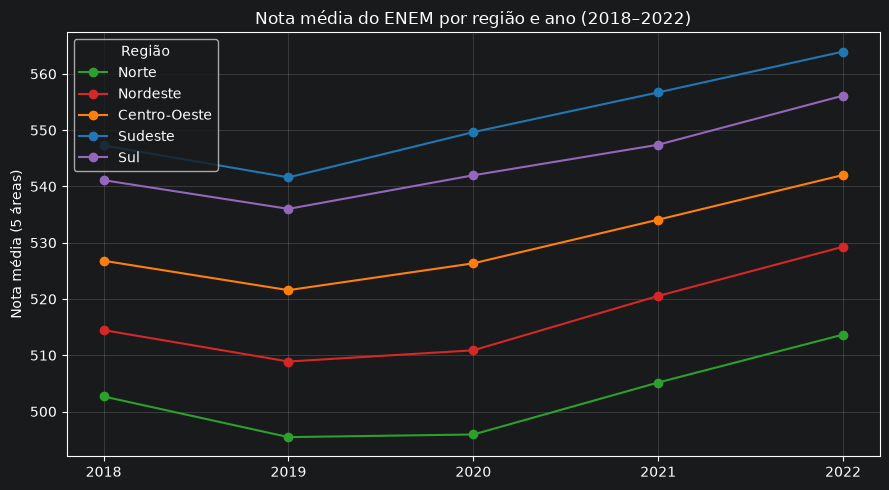

In [24]:
fig,ax=plt.subplots(figsize=(9,5))
cores={'Norte':'#2ca02c','Nordeste':'#d62728','Centro-Oeste':'#ff7f0e','Sudeste':'#1f77b4','Sul':'#9467bd'}
for rg in regs:
    ax.plot(YEARS, [reg_year[rg][y] for y in YEARS], marker='o', color=cores[rg], label=rg)
ax.set_xlabel(''); ax.set_ylabel('Nota média (5 áreas)'); ax.set_xticks(YEARS)
ax.set_title('Nota média do ENEM por região e ano (2018–2022)')
ax.legend(title='Região'); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 3. Renda × nota no indivíduo
### 3.1 Nota média por faixa de renda (nacional, por ano)


In [25]:
rows=[]
for y in YEARS:
    agg=defaultdict(lambda: np.zeros(2))
    for (rg,rank),a in RES[y]['inc_reg'].items(): agg[rank]+=a
    for rank,a in agg.items(): rows.append([y,int(rank),int(a[0]),a[1]/a[0]])
inc_nat=pd.DataFrame(rows,columns=['Ano','Faixa_renda','N','Nota_media']).sort_values(['Ano','Faixa_renda'])
inc_nat.pivot(index='Faixa_renda',columns='Ano',values='Nota_media').round(1)

Ano,2018,2019,2020,2021,2022
Faixa_renda,,,,,
1,482.6,473.0,469.9,476.0,482.3
2,489.2,482.8,487.4,492.9,502.2
3,509.1,503.6,510.9,516.0,527.1
4,526.6,522.5,525.2,528.6,540.4
5,533.8,530.4,542.1,542.1,553.4
6,549.5,546.6,552.6,551.0,565.2
7,557.3,554.9,569.4,564.4,574.0
8,573.6,571.3,583.8,576.0,586.0
9,584.6,579.7,594.6,584.9,596.9


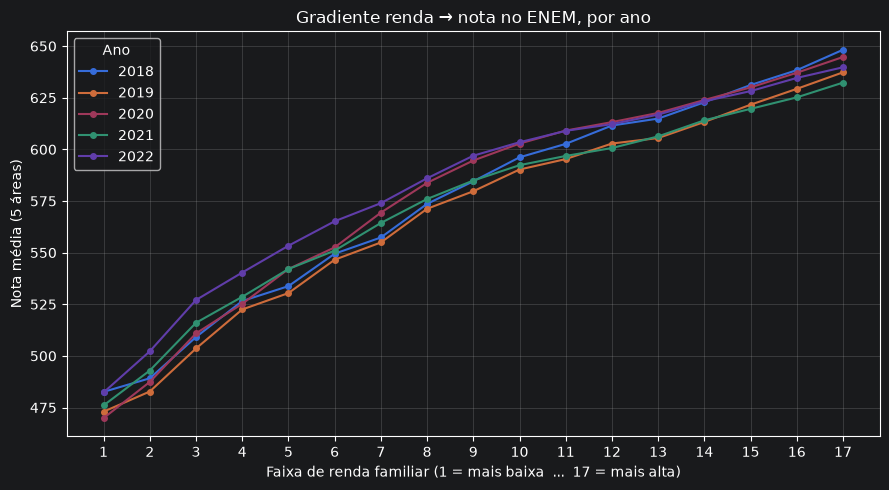

In [26]:
fig,ax=plt.subplots(figsize=(9,5))
for y in YEARS:
    d=inc_nat[inc_nat['Ano']==y]; ax.plot(d['Faixa_renda'], d['Nota_media'], marker='o', ms=4, label=str(y))
ax.set_xlabel('Faixa de renda familiar (1 = mais baixa  ...  17 = mais alta)'); ax.set_ylabel('Nota média (5 áreas)')
ax.set_title('Gradiente renda → nota no ENEM, por ano'); ax.set_xticks(range(1,18)); ax.legend(title='Ano'); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### 3.2 Correlação renda × nota (Pearson), nacional e por região


In [27]:
rows=[]
for y in YEARS:
    r={'Ano':y,'BRASIL':round(corr_from_sums(RES[y]['corr']['BRASIL']),3)}
    for rg in regs: r[rg]=round(corr_from_sums(RES[y]['corr'][rg]),3)
    rows.append(r)
corr_tab=pd.DataFrame(rows)[['Ano','BRASIL']+regs]
corr_tab

,Ano,BRASIL,Norte,Nordeste,Centro-Oeste,Sudeste,Sul
0,2018,0.483,0.408,0.453,0.495,0.472,0.431
1,2019,0.478,0.410,0.450,0.486,0.465,0.429
2,2020,0.474,0.420,0.442,0.482,0.452,0.428
3,2021,0.451,0.419,0.433,0.460,0.415,0.394
4,2022,0.452,0.412,0.429,0.459,0.425,0.410


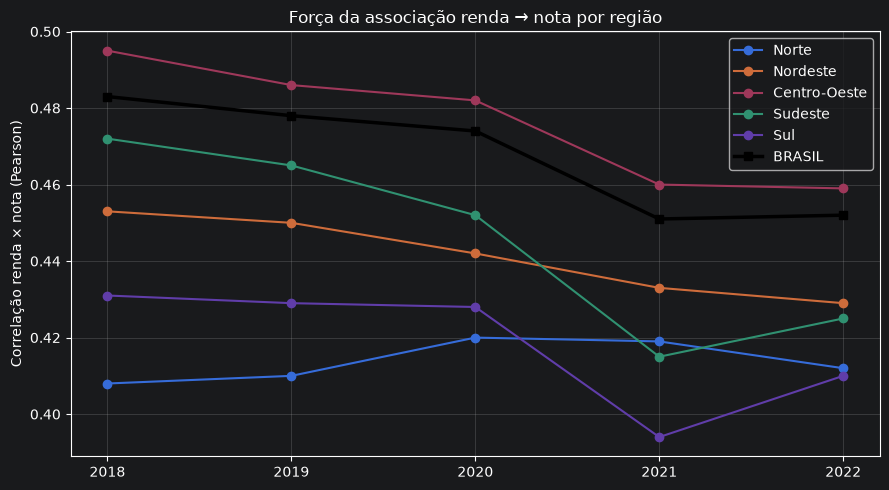

In [28]:
fig,ax=plt.subplots(figsize=(9,5))
for rg in regs: ax.plot(corr_tab['Ano'], corr_tab[rg], marker='o', label=rg)
ax.plot(corr_tab['Ano'], corr_tab['BRASIL'], marker='s', color='black', lw=2.5, label='BRASIL')
ax.set_ylabel('Correlação renda × nota (Pearson)'); ax.set_xticks(YEARS)
ax.set_title('Força da associação renda → nota por região'); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 4. Pública × privada — nota por região e ano


In [29]:
rows=[]
for y in YEARS:
    for (rg,rede),a in RES[y]['pp'].items(): rows.append([y,rg,rede,int(a[0]),a[1]/a[0]])
pp=pd.DataFrame(rows,columns=['Ano','Regiao','Rede','N','Nota_media'])
gap3=pp.pivot_table(index=['Ano','Regiao'],columns='Rede',values='Nota_media')
gap3['Gap']=gap3['Privada']-gap3['Pública']
gap_pp=gap3['Gap'].reset_index().pivot(index='Regiao',columns='Ano',values='Gap').round(1)
gap_pp

Ano,2018,2019,2020,2021,2022
Regiao,,,,,
Centro-Oeste,101.1,101.1,92.0,92.5,93.5
Nordeste,106.6,114.5,102.6,97.1,100.8
Norte,99.7,103.2,101.1,97.1,94.0
Sudeste,94.4,97.7,77.1,72.1,75.3
Sul,81.2,85.2,73.9,72.9,74.0


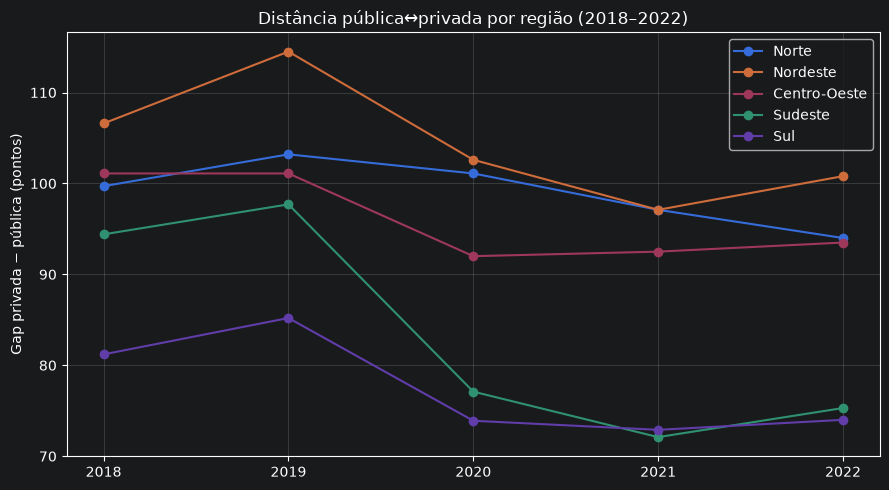

In [30]:
fig,ax=plt.subplots(figsize=(9,5))
for rg in regs:
    if rg in gap_pp.index: ax.plot(gap_pp.columns, gap_pp.loc[rg], marker='o', label=rg)
ax.set_ylabel('Gap privada − pública (pontos)'); ax.set_xticks(YEARS)
ax.set_title('Distância pública↔privada por região (2018–2022)'); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5. Urbano × rural — nota por região e ano


In [31]:
rows=[]
for y in YEARS:
    for (rg,lc),a in RES[y]['loc'].items(): rows.append([y,rg,lc,int(a[0]),a[1]/a[0]])
loc=pd.DataFrame(rows,columns=['Ano','Regiao','Localizacao','N','Nota_media'])
l4=loc.pivot_table(index=['Ano','Regiao'],columns='Localizacao',values='Nota_media')
l4['Gap']=l4['Urbana']-l4['Rural']
gap_ur=l4['Gap'].reset_index().pivot(index='Regiao',columns='Ano',values='Gap').round(1)
gap_ur

Ano,2018,2019,2020,2021,2022
Regiao,,,,,
Centro-Oeste,25.5,22.0,22.6,22.1,26.2
Nordeste,29.6,27.1,40.9,39.1,38.1
Norte,32.8,31.9,33.8,42.4,41.6
Sudeste,15.3,11.3,11.0,14.0,12.3
Sul,22.4,17.3,30.0,25.1,22.9


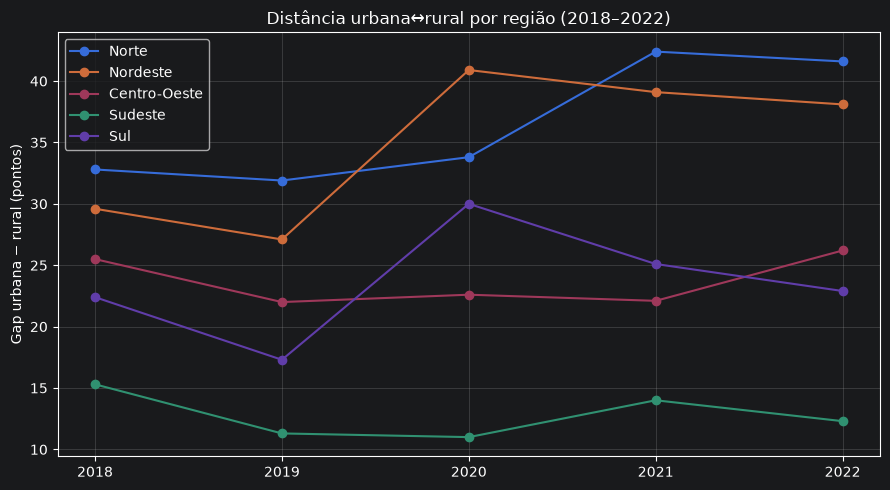

In [32]:
fig,ax=plt.subplots(figsize=(9,5))
for rg in regs:
    if rg in gap_ur.index: ax.plot(gap_ur.columns, gap_ur.loc[rg], marker='o', label=rg)
ax.set_ylabel('Gap urbana − rural (pontos)'); ax.set_xticks(YEARS)
ax.set_title('Distância urbana↔rural por região (2018–2022)'); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 6. Síntese da série temporal


In [33]:
sint=pd.DataFrame({'Ano':YEARS})
sint['Nota_media_nacional']=[round(RES[y]['overall'][1]/RES[y]['overall'][0],1) for y in YEARS]
sint['Presentes']=[int(RES[y]['overall'][0]) for y in YEARS]
sint=sint.merge(corr_tab[['Ano','BRASIL']].rename(columns={'BRASIL':'Corr_renda_nota'}),on='Ano')
sint

,Ano,Nota_media_nacional,Presentes,Corr_renda_nota
0,2018,528.9,3893729,0.483
1,2019,522.6,3701909,0.478
2,2020,526.6,2588681,0.474
3,2021,535.5,2238107,0.451
4,2022,543.5,2344823,0.452


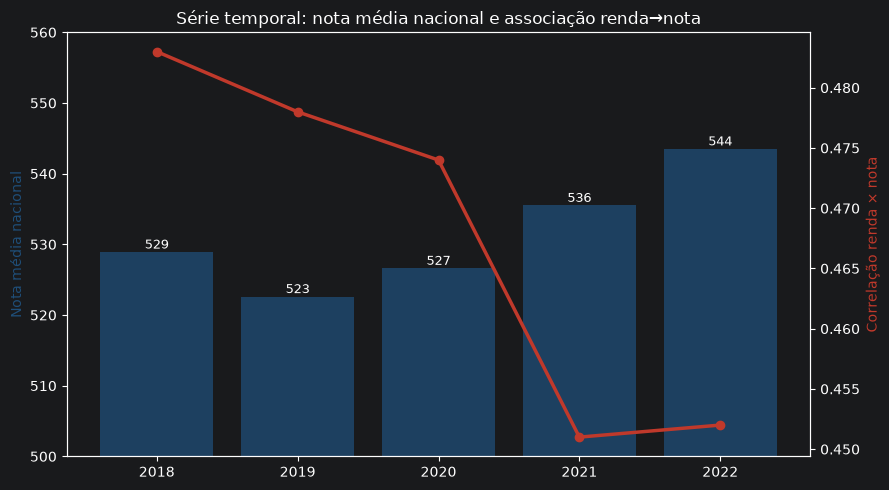

In [34]:
fig,ax=plt.subplots(figsize=(9,5))
ax.bar(sint['Ano'], sint['Nota_media_nacional'], color='#1f4e78', alpha=.75, label='Nota média nacional')
ax.set_ylabel('Nota média nacional', color='#1f4e78'); ax.set_ylim(500, 560); ax.set_xticks(YEARS)
for x,v in zip(sint['Ano'], sint['Nota_media_nacional']): ax.text(x, v+0.5, f'{v:.0f}', ha='center', fontsize=9)
ax2=ax.twinx()
ax2.plot(sint['Ano'], sint['Corr_renda_nota'], marker='o', color='#c0392b', lw=2.5, label='Correlação renda×nota')
ax2.set_ylabel('Correlação renda × nota', color='#c0392b')
ax.set_title('Série temporal: nota média nacional e associação renda→nota'); fig.tight_layout(); plt.show()

## 7. Presença: escola pública vs privada
**Taxa de presença** = presentes nas 4 áreas ÷ inscritos (com rede informada).


In [35]:
rows=[]
for y in YEARS:
    for (rg,rede),a in RES[y]['pres'].items():
        rows.append([y,rg,rede,int(a[0]),int(a[1]), round(a[1]/a[0]*100,1)])
presdf=pd.DataFrame(rows,columns=['Ano','Regiao','Rede','Inscritos','Presentes','Taxa_presenca_%'])
nac=presdf.groupby(['Ano','Rede']).agg(Inscritos=('Inscritos','sum'),Presentes=('Presentes','sum')).reset_index()
nac['Taxa_presenca_%']=(nac['Presentes']/nac['Inscritos']*100).round(1)
tab_nac=nac.pivot(index='Ano',columns='Rede',values='Taxa_presenca_%')
tab_nac['Dif (Priv-Pub)']=(tab_nac['Privada']-tab_nac['Pública']).round(1)
tab_nac

Rede,Privada,Pública,Dif (Priv-Pub)
Ano,,,
2018,94.5,74.6,19.9
2019,94.9,81.2,13.7
2020,80.6,52.7,27.9
2021,93.1,67.4,25.7
2022,91.9,66.8,25.1


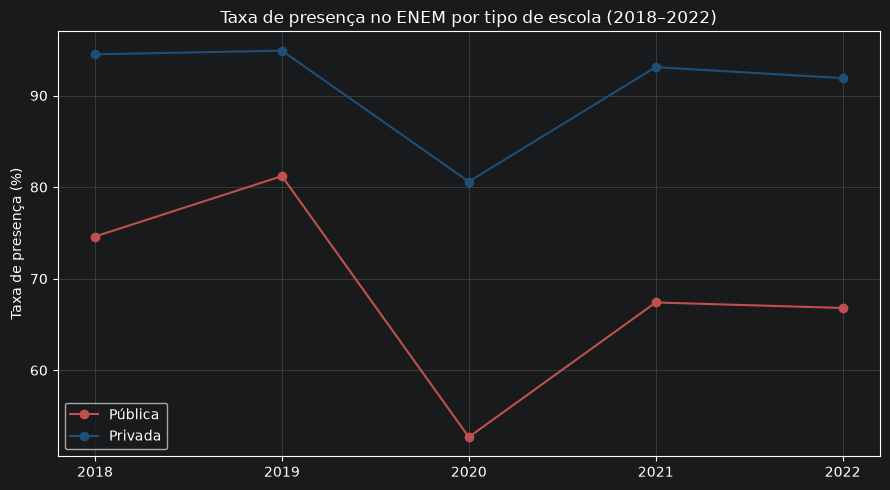

In [36]:
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(tab_nac.index, tab_nac['Pública'], marker='o', color='#c0504d', label='Pública')
ax.plot(tab_nac.index, tab_nac['Privada'], marker='o', color='#1f4e78', label='Privada')
ax.set_ylabel('Taxa de presença (%)'); ax.set_xticks(YEARS)
ax.set_title('Taxa de presença no ENEM por tipo de escola (2018–2022)'); ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### 7.1 Taxa de presença por região, rede e ano


In [37]:
presdf.pivot_table(index=['Regiao','Rede'],columns='Ano',values='Taxa_presenca_%')

Ano                   2018  2019  2020  2021  2022
Regiao       Rede                                 
Centro-Oeste Privada  94.3  94.4  82.1  93.6  91.5
             Pública  74.6  84.0  50.5  58.9  60.4
Nordeste     Privada  96.8  96.9  88.7  95.5  94.8
             Pública  75.4  81.7  53.7  66.8  69.0
Norte        Privada  95.2  95.0  82.2  93.0  91.1
             Pública  74.8  82.1  46.3  58.7  61.0
Sudeste      Privada  94.3  95.1  78.2  93.0  92.0
             Pública  73.9  80.0  53.6  72.8  67.7
Sul          Privada  90.0  91.0  75.0  89.8  87.7
             Pública  74.1  80.4  55.5  72.2  68.9

In [38]:
def painel_indicador(indic, nome, cor_ind):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.ravel()
    for i, rg in enumerate(regs):
        ax = axes[i]
        notas = [reg_year[rg][y] for y in YEARS]; vals = indic[rg]
        l1, = ax.plot(YEARS, notas, marker='o', color='#1f4e78', label='Nota média ENEM')
        ax.set_ylabel('Nota média ENEM', color='#1f4e78'); ax.tick_params(axis='y', labelcolor='#1f4e78')
        ax2 = ax.twinx()
        l2, = ax2.plot(YEARS, vals, marker='s', linestyle='--', color=cor_ind, label=nome)
        ax2.set_ylabel(nome, color=cor_ind); ax2.tick_params(axis='y', labelcolor=cor_ind)
        ax.set_title(rg, fontweight='bold'); ax.set_xticks(YEARS); ax.grid(alpha=.25)
    axes[-1].axis('off')
    axes[-1].legend(handles=[l1, l2], loc='center', fontsize=12, frameon=True)
    fig.suptitle(f'Nota média do ENEM × {nome} por região (2018–2022)', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

## 8. Nota do ENEM × IDHM por região



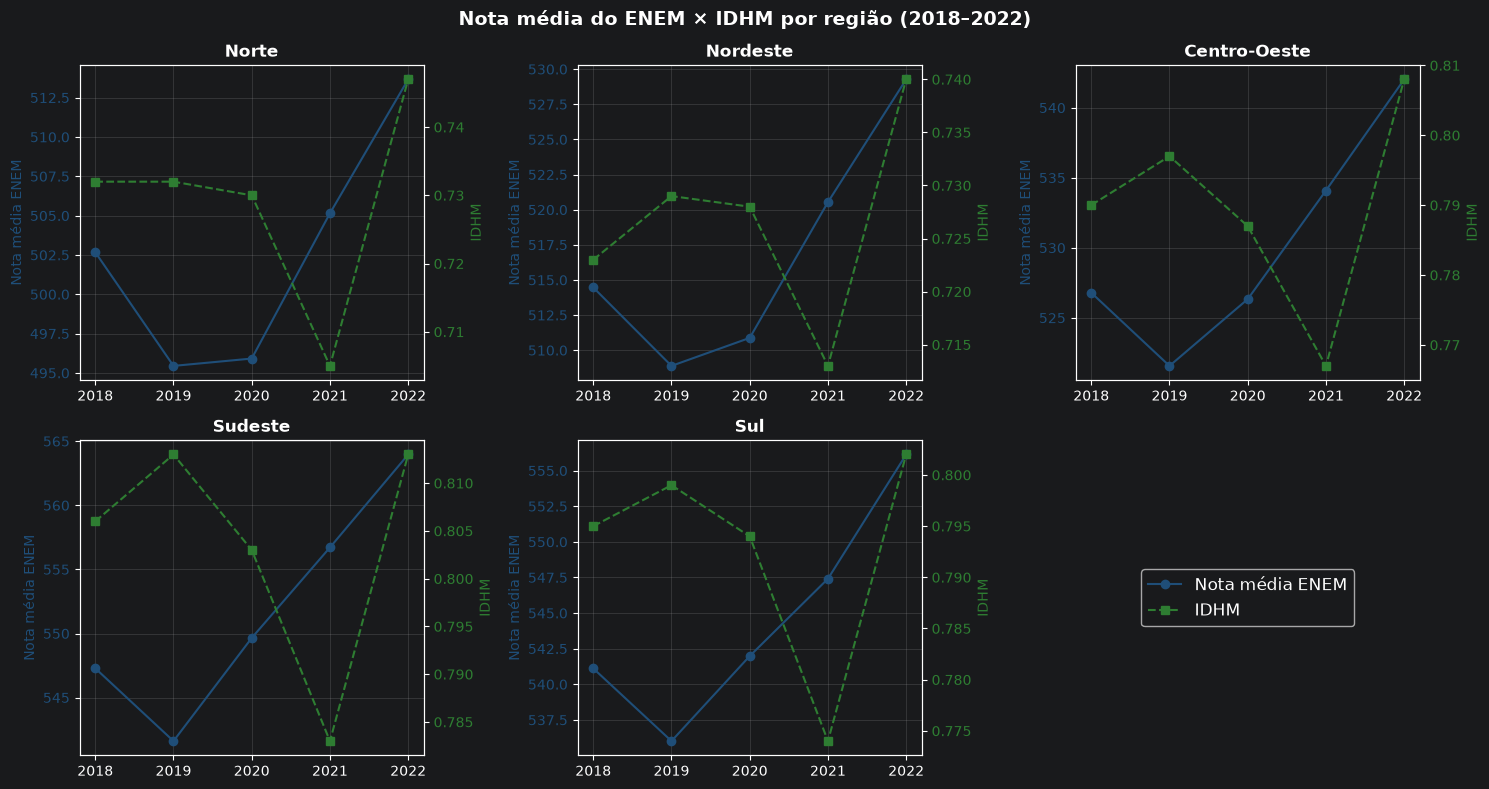

In [39]:
painel_indicador(IDHM, 'IDHM', '#2e7d32')

## 9. Nota do ENEM × IVS por região



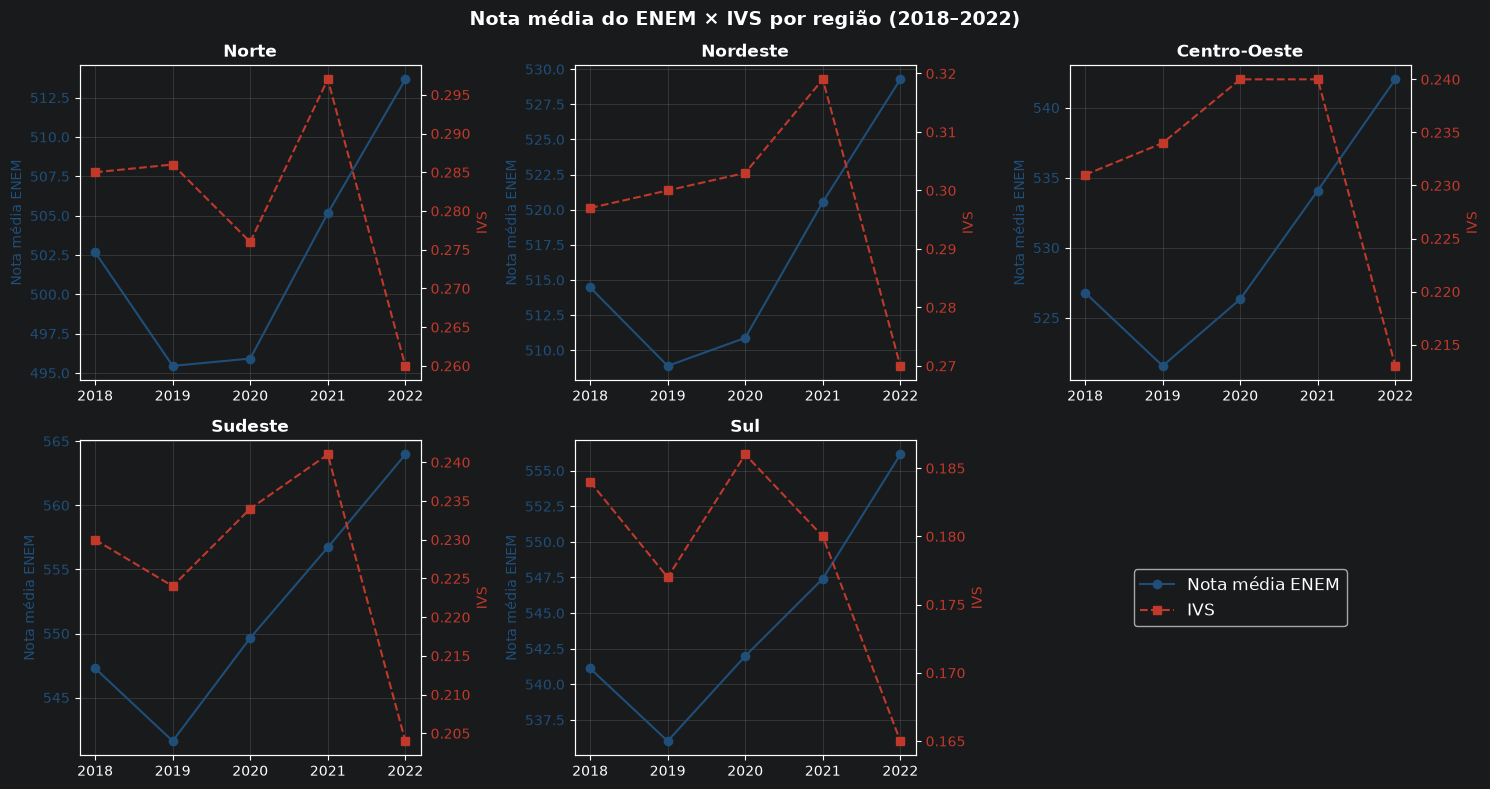

In [40]:
painel_indicador(IVS, 'IVS', '#c0392b')